# Sleep Quality and Disease Risk Early Warning System



Plan:

1. Load and inspect raw data
2. Fill missing Sleep Disorder values with None
3. Split Blood Pressure into two columns
4. Encode categorical columns
5. Perform EDA
6. Clustering
7. Classification
8. SHAP
9. Streamlit

## ⚙️ Project Configuration

This cell sets up the folder structure for the project.  
All file paths are managed from a single location so the rest of the code never needs to be changed if paths change.

- `data/` — raw dataset
- `outputs/` — saved charts
- `models/` — trained model files

In [12]:
import os
import shutil

DATA_DIR = "data"
OUTPUT_DIR = "outputs"
MODEL_DIR = "models"


DATA_PATH = os.path.join(DATA_DIR, "Sleep_health_and_lifestyle_dataset.csv")
GRAPH_OUTPUT_PATH = os.path.join(OUTPUT_DIR, "sleep_disorder_distribution.png")
MODEL_OUTPUT_PATH = os.path.join(MODEL_DIR, "best_sleep_model.joblib")

for directory in [DATA_DIR, OUTPUT_DIR, MODEL_DIR]:
    os.makedirs(directory, exist_ok=True)


if os.path.exists("Sleep_health_and_lifestyle_dataset.csv"):
    shutil.move("Sleep_health_and_lifestyle_dataset.csv", DATA_PATH)
    print("[INFO] Dataset successfully moved to 'data/' folder.")

In [2]:
#libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

print("Libraries loaded")

Libraries loaded


---
## 📥 Section 1 — Data Loading & Exploration

We load the dataset and take a first look at its structure: how many rows and columns exist, what data types we have, and whether there are any missing values.

## Section 1 - Data Loading and Exploration

In [3]:
# Load the dataset
df = pd.read_csv(DATA_PATH)

# Check number of rows and columns
print("Number of rows and columns:", df.shape)

# Column names and data types
print("\nColumn info:")
print(df.dtypes)

# Preview first 5 rows
print("\nFirst 5 rows:")
df.head()

Number of rows and columns: (374, 13)

Column info:
Person ID                    int64
Gender                      object
Age                          int64
Occupation                  object
Sleep Duration             float64
Quality of Sleep             int64
Physical Activity Level      int64
Stress Level                 int64
BMI Category                object
Blood Pressure              object
Heart Rate                   int64
Daily Steps                  int64
Sleep Disorder              object
dtype: object

First 5 rows:


,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


In [4]:
# Check missing values
print("Missing values:")
print(df.isnull().sum())

# Basic statistics
print("\nBasic statistics:")
df.describe()

Missing values:
Person ID                    0
Gender                       0
Age                          0
Occupation                   0
Sleep Duration               0
Quality of Sleep             0
Physical Activity Level      0
Stress Level                 0
BMI Category                 0
Blood Pressure               0
Heart Rate                   0
Daily Steps                  0
Sleep Disorder             219
dtype: int64

Basic statistics:


,Person ID,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps
count,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000
mean,187.500000,42.184492,7.132086,7.312834,59.171123,5.385027,70.165775,6816.844920
std,108.108742,8.673133,0.795657,1.196956,20.830804,1.774526,4.135676,1617.915679
min,1.000000,27.000000,5.800000,4.000000,30.000000,3.000000,65.000000,3000.000000
25%,94.250000,35.250000,6.400000,6.000000,45.000000,4.000000,68.000000,5600.000000
50%,187.500000,43.000000,7.200000,7.000000,60.000000,5.000000,70.000000,7000.000000
75%,280.750000,50.000000,7.800000,8.000000,75.000000,7.000000,72.000000,8000.000000
max,374.000000,59.000000,8.500000,9.000000,90.000000,8.000000,86.000000,10000.000000


### 🔍 Key Findings from Exploration

- **219 missing values** in `Sleep Disorder` — these represent people with **no disorder**, not truly missing data. We will fill them with `"None"`.
- Average age is **42**, ranging from 27 to 59.
- Average sleep duration is **7.1 hours** (min 5.8 — max 8.5).
- Stress levels range from **3 to 8**, with an average of 5.4.


## 🧹 Section 2 — Data Cleaning & Preprocessing

Before building any model, we need to clean and transform the raw data:

1. Fill missing `Sleep Disorder` values with `"None"`
2. Split `Blood Pressure` (e.g. `"120/80"`) into two separate numeric columns: `Systolic_BP` and `Diastolic_BP`
3. Encode categorical columns (Gender, Occupation, BMI Category) into numbers so machine learning algorithms can use them

In [7]:
# Fill missing Sleep Disorder values with 'None' (no disorder)
# NaN means the person has no sleep disorder
df['Sleep Disorder'] = df['Sleep Disorder'].fillna('None')

# Verify the result
print(df['Sleep Disorder'].value_counts())

Sleep Disorder
None           219
Sleep Apnea     78
Insomnia        77
Name: count, dtype: int64


In [8]:
# Reload and clean data for clustering
df_processed = pd.read_csv(DATA_PATH)

# Fill missing Sleep Disorder values with 'None' (no disorder)
df_processed['Sleep Disorder'] = df_processed['Sleep Disorder'].fillna('None')

# Split Blood Pressure into Systolic and Diastolic
df_processed[['Systolic_BP', 'Diastolic_BP']] = df_processed['Blood Pressure'].str.split('/', expand=True).astype(int)
df_processed = df_processed.drop('Blood Pressure', axis=1)

# Encode categorical columns to numeric
le = LabelEncoder()
categorical_cols = ['Gender', 'Occupation', 'BMI Category', 'Sleep Disorder']

for col in categorical_cols:
    df_processed[col] = le.fit_transform(df_processed[col])

print("Data ready for clustering: df_processed")
print(df_processed.dtypes)
df_processed.head()

Data ready for clustering: df_processed
Person ID                    int64
Gender                       int64
Age                          int64
Occupation                   int64
Sleep Duration             float64
Quality of Sleep             int64
Physical Activity Level      int64
Stress Level                 int64
BMI Category                 int64
Heart Rate                   int64
Daily Steps                  int64
Sleep Disorder               int64
Systolic_BP                  int64
Diastolic_BP                 int64
dtype: object


,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Heart Rate,Daily Steps,Sleep Disorder,Systolic_BP,Diastolic_BP
0,1,1,27,9,6.1,6,42,6,3,77,4200,1,126,83
1,2,1,28,1,6.2,6,60,8,0,75,10000,1,125,80
2,3,1,28,1,6.2,6,60,8,0,75,10000,1,125,80
3,4,1,28,6,5.9,4,30,8,2,85,3000,2,140,90
4,5,1,28,6,5.9,4,30,8,2,85,3000,2,140,90


---
## 📊 Section 3 — Exploratory Data Analysis (EDA)

EDA helps us **understand the data before building any model**.  
We create visualizations to answer key questions:
- How is sleep duration distributed across the population?
- Which occupations have the highest stress levels?
- How does BMI relate to sleep disorders?
- What is the correlation between stress and sleep quality?

Skipping EDA means building a model blindly.

### 📈 Chart 1 — Sleep Duration Distribution

Shows how sleep duration is spread across the dataset.  
The dashed red line marks the **population mean**.  
We check whether the distribution is normal or skewed, and identify any outliers.

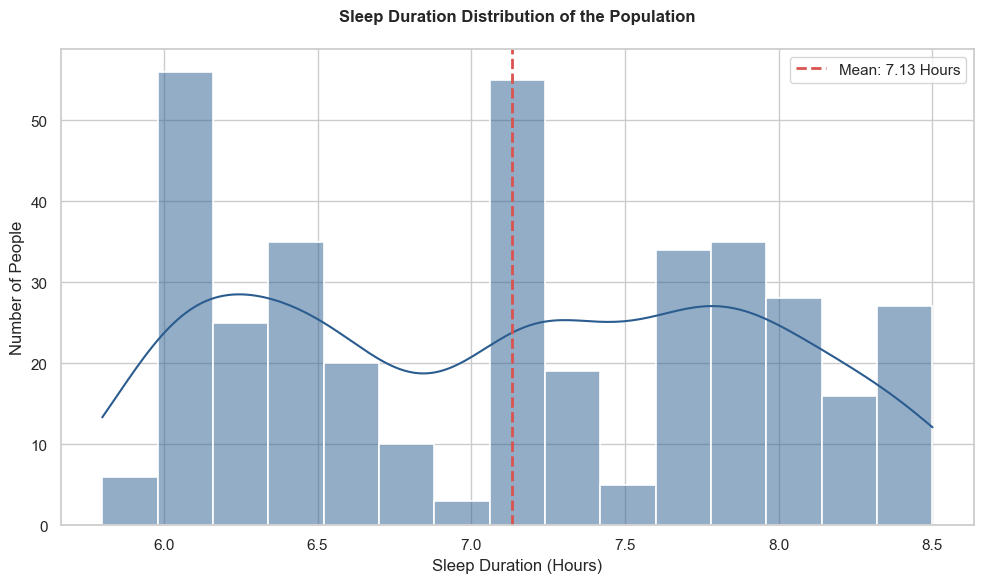

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")  
plt.figure(figsize=(10, 6))


sns.histplot(
    data=df,
    x="Sleep Duration",
    bins=15,
    kde=True,
    color="#2b5c8f",
    edgecolor="white",
    linewidth=1.2,
)


mean_sleep = df_processed["Sleep Duration"].mean()
plt.axvline(
    mean_sleep,
    color="#d9534f",
    linestyle="--",
    linewidth=2,
    label=f"Mean: {mean_sleep:.2f} Hours",
)


plt.title("Sleep Duration Distribution of the Population", pad=20, fontweight="bold")
plt.xlabel("Sleep Duration (Hours)")
plt.ylabel("Number of People")
plt.legend(loc="upper right")
plt.tight_layout()


plt.savefig("outputs/sleep_duration_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

### 📊 Chart 2 — Sleep Disorder Distribution

Shows how many people fall into each category: **None**, **Insomnia**, and **Sleep Apnea**.  
This tells us whether the dataset is **balanced or imbalanced**, which directly affects model training.

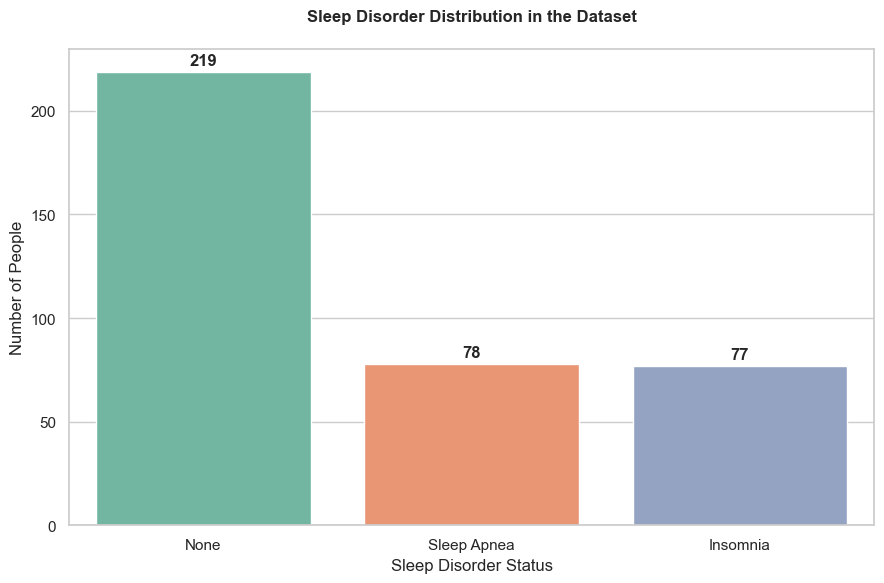

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

df_temp = pd.read_csv(DATA_PATH)
df_temp['Sleep Disorder'] = df_temp['Sleep Disorder'].fillna('None')

sns.set_theme(style="whitegrid")  
plt.figure(figsize=(9, 6))

ax = sns.countplot(
    data=df_temp,
    x="Sleep Disorder",
    palette="Set2",
    hue="Sleep Disorder",
    legend=False,
)


for p in ax.patches:
    ax.annotate(
        f"{int(p.get_height())}",
        (p.get_x() + p.get_width() / 2.0, p.get_height()),
        ha="center",
        va="center",
        xytext=(0, 8),
        textcoords="offset points",
        fontweight="bold",
    )


plt.title("Sleep Disorder Distribution in the Dataset", pad=20, fontweight="bold")
plt.xlabel("Sleep Disorder Status")
plt.ylabel("Number of People")
plt.tight_layout()


plt.savefig("outputs/sleep_disorder_distribution.png", dpi=300, bbox_inches="tight")

# Ekranda göster
plt.show()

### 🔴 Chart 3 — Stress Level vs Sleep Quality

A scatter plot colored by sleep disorder type.  
**Expected insight:** as stress increases, sleep quality drops.  
We also look at which disorder types cluster at high-stress, low-quality regions.

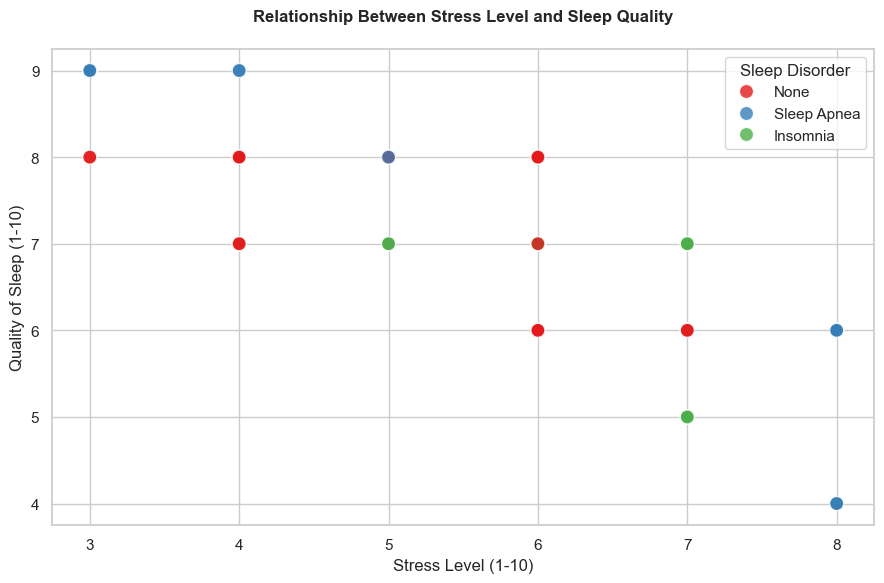

In [11]:
#Relationship Between Stress Level and Sleep Quality
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")  
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df_temp,
    x="Stress Level",
    y="Quality of Sleep",
    hue="Sleep Disorder",
    palette="Set1",
    s=100,
    alpha=0.8,
)

plt.title("Relationship Between Stress Level and Sleep Quality", pad=20, fontweight="bold")
plt.xlabel("Stress Level (1-10)")
plt.ylabel("Quality of Sleep (1-10)")
plt.legend(title="Sleep Disorder", loc="upper right", frameon=True)
plt.tight_layout()
plt.savefig("outputs/stress_sleep_relationship.png", dpi=300, bbox_inches="tight")
plt.show()

### 🌡️ Chart 4 — Correlation Matrix

Shows the **strength of linear relationships** between all numeric features.

Key findings:
- `Sleep Duration` ↔ `Quality of Sleep`: **+0.88** — more sleep = better quality
- `Stress Level` ↔ `Quality of Sleep`: **-0.90** — more stress = worse quality (very strong)
- `Systolic_BP` ↔ `Diastolic_BP`: **+0.97** — nearly identical, one could be dropped
- `BMI Category` ↔ `Systolic_BP`: **+0.71** — overweight individuals tend to have higher BP

These relationships guide which features will be most important in our model.

Data ready for clustering: df_processed
Person ID                    int64
Gender                       int64
Age                          int64
Occupation                   int64
Sleep Duration             float64
Quality of Sleep             int64
Physical Activity Level      int64
Stress Level                 int64
BMI Category                 int64
Heart Rate                   int64
Daily Steps                  int64
Sleep Disorder               int64
Systolic_BP                  int64
Diastolic_BP                 int64
dtype: object


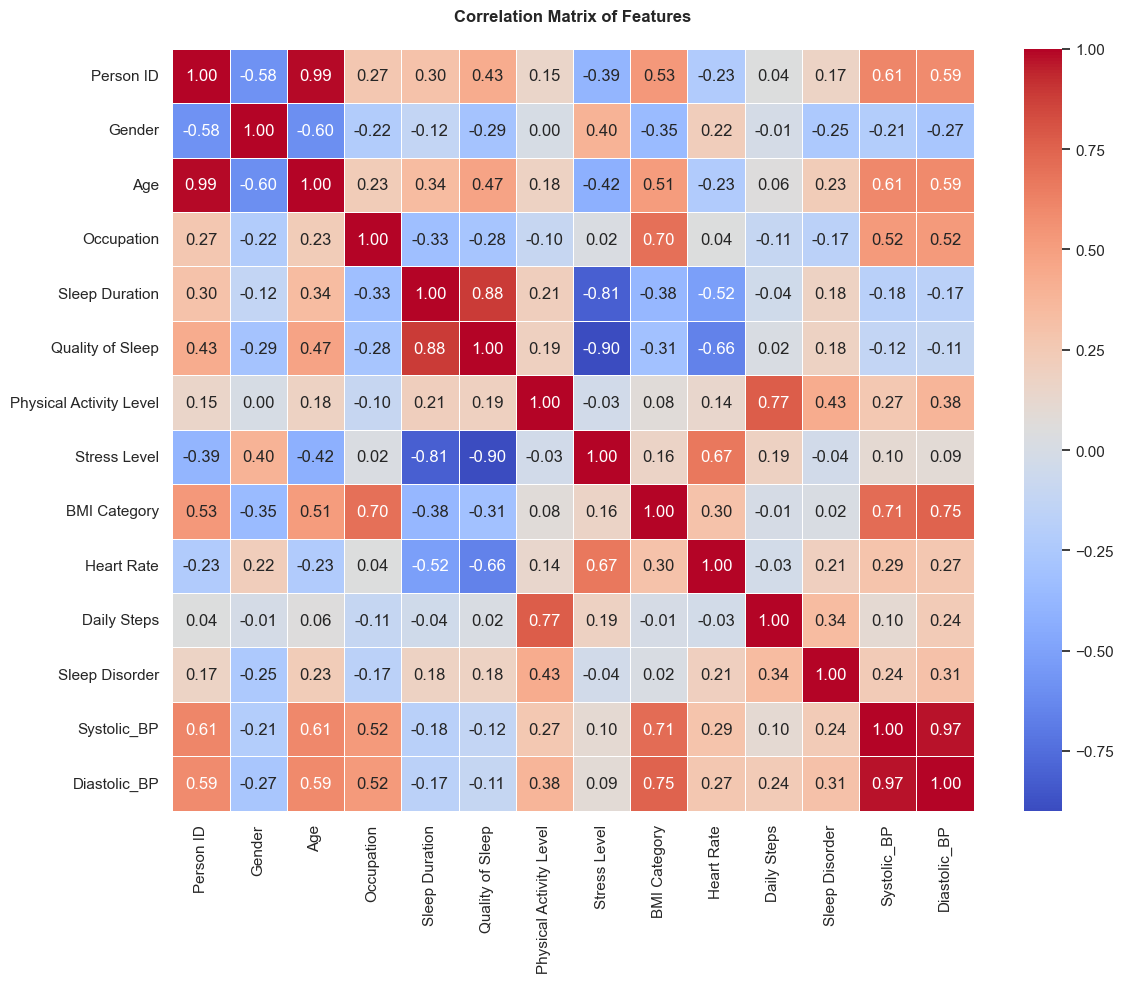

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

df_processed = pd.read_csv(DATA_PATH)

# Fill missing Sleep Disorder values with 'None' (no disorder)
df_processed['Sleep Disorder'] = df_processed['Sleep Disorder'].fillna('None')

# Split Blood Pressure into Systolic and Diastolic
df_processed[['Systolic_BP', 'Diastolic_BP']] = df_processed['Blood Pressure'].str.split('/', expand=True).astype(int)
df_processed = df_processed.drop('Blood Pressure', axis=1)

# Encode categorical columns to numeric
le = LabelEncoder()
kategorik_kolonlar_to_encode = ['Gender', 'Occupation', 'BMI Category', 'Sleep Disorder']

for kolon in kategorik_kolonlar_to_encode:
    df_processed[kolon] = le.fit_transform(df_processed[kolon])

print("Data ready for clustering: df_processed")
print(df_processed.dtypes)
plt.figure(figsize=(12, 10))

sns.heatmap(
    df_processed.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
)

plt.title(
    "Correlation Matrix of Features",
    pad=20,
    fontweight="bold",
)
plt.tight_layout()

plt.savefig("outputs/correlation_matrix.png", dpi=300, bbox_inches="tight")

# Ekranda göster
plt.show()

### 🧓 Chart 5 — Age vs Sleep Quality

People over 50 report high sleep quality scores, but many of them carry **Sleep Apnea** risk.  
This suggests older individuals may feel they sleep well while actually being at risk.

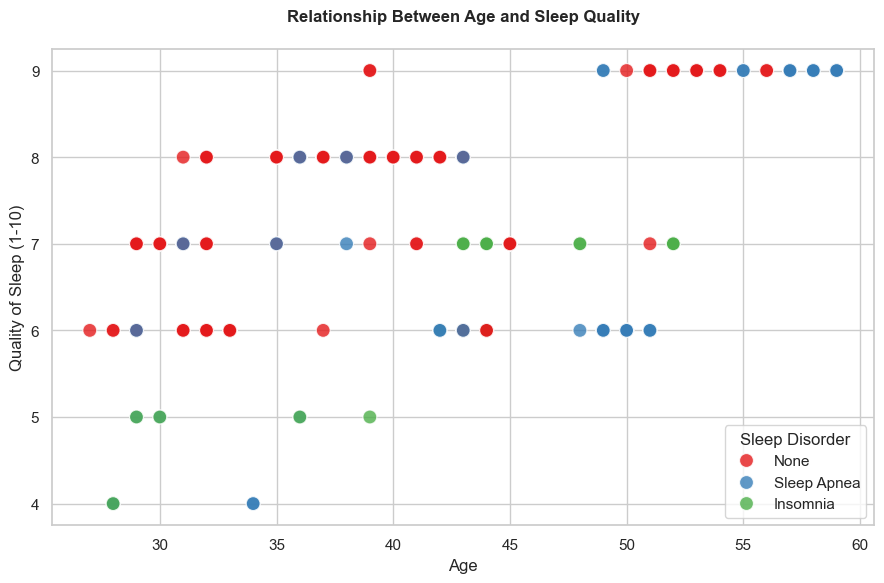

In [ ]:
# Relationship Between Age and Sleep Quality
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")  # Arkası çizgili profesyonel tema
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df_temp,
    x="Age",
    y="Quality of Sleep",
    hue="Sleep Disorder",
    palette="Set1",
    s=100,
    alpha=0.8,
)
plt.title("Relationship Between Age and Sleep Quality", pad=20, fontweight="bold")
plt.xlabel("Age")
plt.ylabel("Quality of Sleep (1-10)")
plt.legend(title="Sleep Disorder", loc="lower right", frameon=True)
plt.tight_layout()
plt.savefig("outputs/age_sleep_relationship.png", dpi=300, bbox_inches="tight")
plt.show()

### 💼 Chart 6 — Stress Level by Occupation

Box plots show the **distribution of stress levels** for each profession.  
Sales Representatives and Teachers tend to show the highest stress, while Scientists and Engineers show lower levels.

In [ ]:
# Check occupation label encodings
df_temp = pd.read_csv(DATA_PATH)
print(df_temp['Occupation'].unique())

['Software Engineer' 'Doctor' 'Sales Representative' 'Teacher' 'Nurse'
 'Engineer' 'Accountant' 'Scientist' 'Lawyer' 'Salesperson' 'Manager']


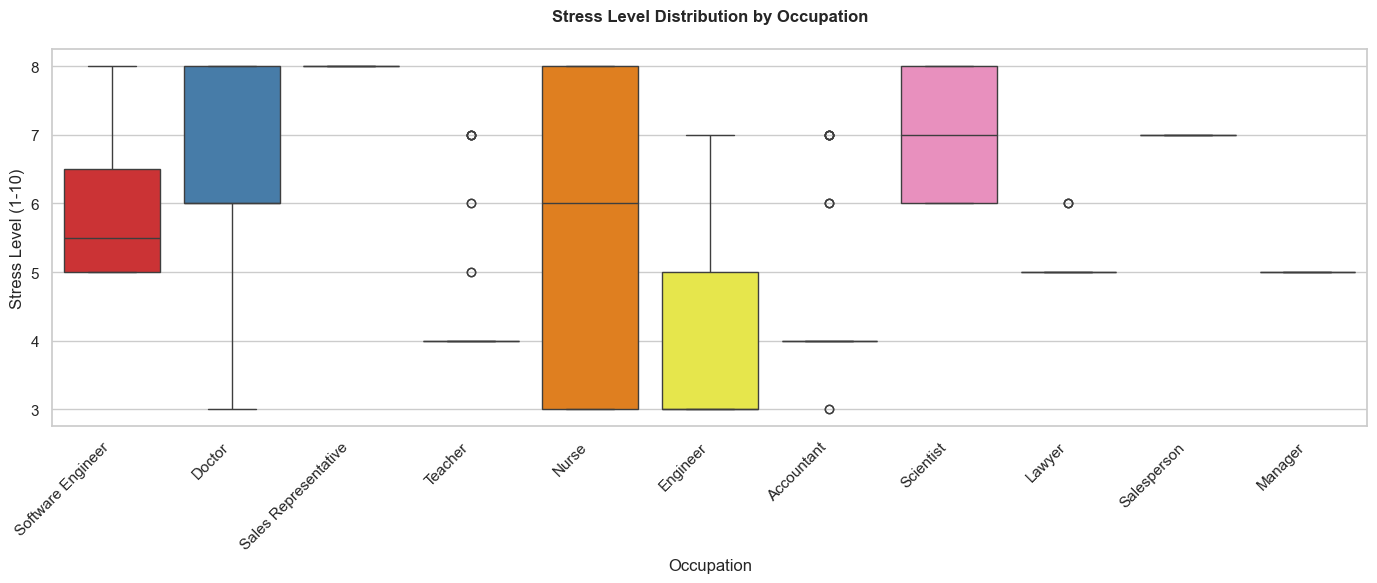

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid") 
plt.figure(figsize=(14, 6))  


sns.boxplot(data=df_temp, x="Occupation", y="Stress Level", hue="Occupation", palette="Set1", legend=False)
plt.title("Stress Level Distribution by Occupation", pad=20, fontweight="bold")
plt.xlabel("Occupation")
plt.ylabel("Stress Level (1-10)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("outputs/occupation_stress.png", dpi=300, bbox_inches="tight")
plt.show()

### ⚖️ Chart 7 — Sleep Disorder by BMI Category

Key findings:
- **Normal weight** individuals: majority have **no disorder** (180 people)
- **Overweight** individuals: Sleep Apnea and Insomnia are nearly equal and high (~65 people each)
- **Obese** individuals: small sample but high disorder rate

**Conclusion:** excess weight is strongly associated with sleep disorders — an important feature for the model.

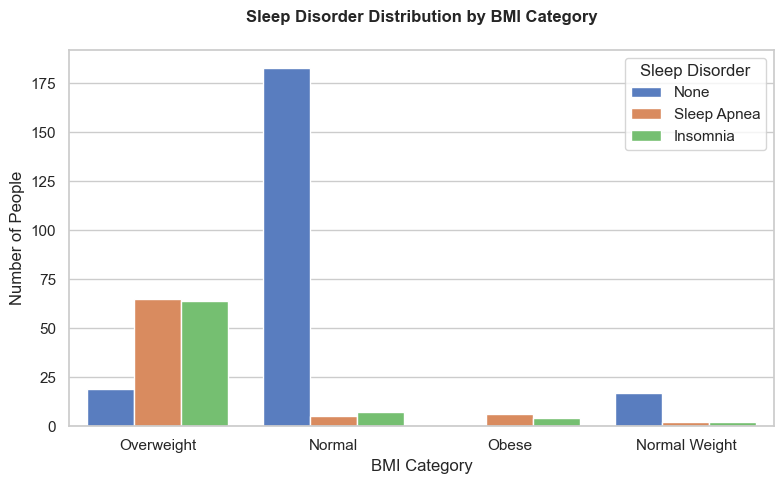

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

df_temp = pd.read_csv(DATA_PATH)
df_temp['Sleep Disorder'] = df_temp['Sleep Disorder'].fillna('None')

sns.set_theme(style="whitegrid") 
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df_temp, x="BMI Category", hue="Sleep Disorder", palette="muted"
)
plt.title(
    "Sleep Disorder Distribution by BMI Category",
    pad=20,
    fontweight="bold",
)
plt.xlabel("BMI Category")
plt.ylabel("Number of People")
plt.legend(title="Sleep Disorder", loc="upper right", frameon=True)
plt.tight_layout()

plt.savefig("outputs/bmi_sleep_disorder.png", dpi=300, bbox_inches="tight")
plt.show()

### 🏃 Chart 8 — Physical Activity vs Sleep Quality

- Higher activity levels (75+ min/day) correlate with sleep quality scores of 8–9
- Low activity (30–40 min/day) shows more Insomnia cases
- Sleep Apnea appears across **all** activity levels — physical activity does not protect against it

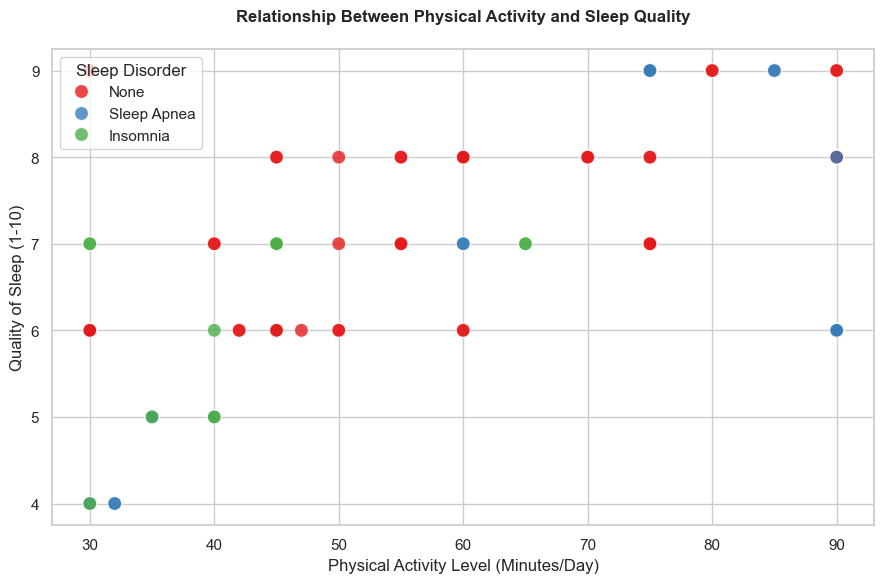

In [ ]:
# Relationship Between Physical Activity and Sleep Quality

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")  
plt.figure(figsize=(9, 6))


sns.scatterplot(
    data=df_temp,
    x="Physical Activity Level",
    y="Quality of Sleep",
    hue="Sleep Disorder",
    palette="Set1",
    s=100,
    alpha=0.8,
)

plt.title("Relationship Between Physical Activity and Sleep Quality", pad=20, fontweight="bold")
plt.xlabel("Physical Activity Level (Minutes/Day)")
plt.ylabel("Quality of Sleep (1-10)")

plt.legend(title="Sleep Disorder", loc="upper left", frameon=True)
plt.tight_layout()

plt.savefig("outputs/activity_sleep.png", dpi=300, bbox_inches="tight")
plt.show()

---
## 🔵 Section 4 — Unsupervised Learning: Sleep Profile Clustering

We have 374 individuals. Instead of manually labeling them, we let **KMeans** discover natural groupings based on similar characteristics.

**Why clustering first?**  
The cluster label becomes an **extra feature** for the supervised model later — giving it richer context about each person's overall profile.

**Types of machine learning:**
| Type | Labels needed? | Used for |
|---|---|---|
| **Supervised** | ✅ Yes | Predicting Sleep Disorder |
| **Unsupervised** | ❌ No | Discovering sleep profiles |
| **Reinforcement** | ❌ No | Games, robotics, ChatGPT |

In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Select features for clustering
# Drop Person ID as it's not a useful feature
X = df_processed.drop(['Person ID', 'Sleep Disorder'], axis=1)

# Scale the data
# KMeans is sensitive to scale
# Scaling ensures all features have equal weight
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Ready for clustering, shape:", X_scaled.shape)

Ready for clustering, shape: (374, 12)


### 📐 Elbow Method — Finding the Optimal k

KMeans requires us to specify the number of clusters upfront.  
The Elbow Method runs KMeans for k = 2 to 10 and plots the **inertia** (within-cluster variance).  
The point where the curve bends sharply (like an elbow) is the optimal k.  
In our case, **k = 4** is the sweet spot.

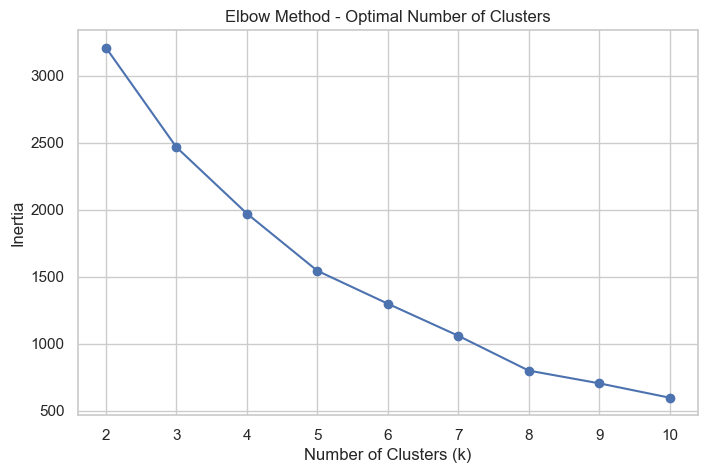

In [ ]:
# Elbow method to find the optimal number of clusters
# Run KMeans for each k and record inertia
inertia = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Plot the elbow curve
plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia, marker='o')
plt.title('Elbow Method - Optimal Number of Clusters')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.savefig("outputs/elbow.png", dpi=300, bbox_inches="tight")
plt.show()

### 👥 Cluster Profiles

| Cluster | Profile | Key Characteristics |
|---|---|---|
| **0** | 😊 Healthy Sleepers | Sleep 7.66h, quality 8.02, low stress 4.54, normal BP |
| **1** | 🚨 High Risk | Sleep only 6.07h, stress 8.00, high BP 140/95 |
| **2** | ⚠️ Moderate Risk | Sleep 6.35h, stress 7.17, low activity 40min/day |
| **3** | 🧓 Elderly/High BP | Oldest group (avg 51.8), high BP but good sleep quality |

In [ ]:
# Build KMeans model with 4 clusters
kmeans = KMeans(n_clusters=4, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)

# Count people in each cluster
print("Number of people in each cluster:")
print(df['Cluster'].value_counts())

Number of people in each cluster:
Cluster
0    178
2    102
3     62
1     32
Name: count, dtype: int64


In [ ]:
# Examine average values per cluster
# This helps us understand each cluster's profile
# Examine average values per cluster
# Add Cluster column to df_processed
df_processed['Cluster'] = df['Cluster']

# Now examine the profiles
cluster_profile = df_processed.groupby('Cluster').mean().round(2)
print(cluster_profile)

         Person ID  Gender    Age  Occupation  Sleep Duration  \
Cluster                                                         
0           158.61    0.59  39.97        2.10            7.66   
1           284.97    0.00  49.75        5.00            6.07   
2           136.57    0.80  37.83        4.32            6.35   
3           303.92    0.03  51.79        7.05            7.44   

         Quality of Sleep  Physical Activity Level  Stress Level  \
Cluster                                                            
0                    8.02                    63.46          4.54   
1                    6.00                    90.00          8.00   
2                    6.00                    40.44          7.17   
3                    8.13                    61.77          3.53   

         BMI Category  Heart Rate  Daily Steps  Sleep Disorder  Systolic_BP  \
Cluster                                                                       
0                0.10       68.19      713

### 🎯 Cluster Visualization

The scatter plot confirms clusters are **well-separated** — KMeans performed well.  
Each cluster occupies a distinct region in the Stress Level vs Sleep Duration space.

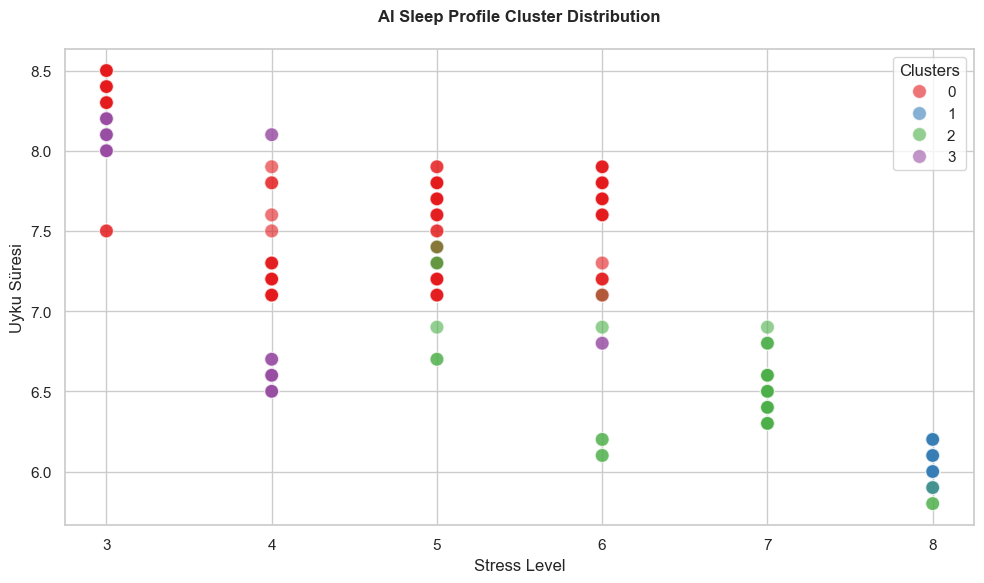

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid") 
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df_processed,
    x="Stress Level",
    y="Sleep Duration",
    hue="Cluster",
    palette="Set1",
    s=100,  
    alpha=0.6,  
)

plt.title("AI Sleep Profile Cluster Distribution", pad=20, fontweight="bold")
plt.xlabel("Stress Level")
plt.ylabel("Sleep Duration")
plt.legend(title="Clusters", loc="upper right", frameon=True)
plt.tight_layout()
plt.savefig("outputs/clusters.png", dpi=300, bbox_inches="tight")
plt.show()

---
## 🤖 Section 5 — Supervised Learning: Sleep Disorder Prediction

Now we use the labeled `Sleep Disorder` column to train classification models.  
We compare 4 algorithms to find the best performer.

**How it works:**
1. `fit` — the model learns patterns from training data
2. `predict` — the model predicts labels for unseen test data
3. We compare predictions to real labels to measure accuracy

In [ ]:

print(df_processed.dtypes)
print(df_processed.head())

Person ID                    int64
Gender                       int64
Age                          int64
Occupation                   int64
Sleep Duration             float64
Quality of Sleep             int64
Physical Activity Level      int64
Stress Level                 int64
BMI Category                 int64
Heart Rate                   int64
Daily Steps                  int64
Sleep Disorder               int64
Systolic_BP                  int64
Diastolic_BP                 int64
Cluster                      int32
dtype: object
   Person ID  Gender  Age  Occupation  Sleep Duration  Quality of Sleep  \
0          1       1   27           9             6.1                 6   
1          2       1   28           1             6.2                 6   
2          3       1   28           1             6.2                 6   
3          4       1   28           6             5.9                 4   
4          5       1   28           6             5.9                 4   

   Physica

**Encoding**

In [ ]:
# we need the new df_raw for the supervısed learnıng
df_raw = pd.read_csv(DATA_PATH)
df_raw['Sleep Disorder'] = df_raw['Sleep Disorder'].fillna('None')
df_raw[['Systolic_BP', 'Diastolic_BP']] = df_raw['Blood Pressure'].str.split('/', expand=True).astype(int)
df_raw = df_raw.drop(['Blood Pressure', 'Person ID'], axis=1)
df_raw['Cluster'] = kmeans.predict(X_scaled)

print(df_raw.dtypes)

Gender                      object
Age                          int64
Occupation                  object
Sleep Duration             float64
Quality of Sleep             int64
Physical Activity Level      int64
Stress Level                 int64
BMI Category                object
Heart Rate                   int64
Daily Steps                  int64
Sleep Disorder              object
Systolic_BP                  int64
Diastolic_BP                 int64
Cluster                      int32
dtype: object


### 🔧 Feature Engineering & Encoding Strategy

Different column types need different encoding:
- **Nominal** (no order): `Gender`, `Occupation` → **OneHotEncoder** (creates binary columns)
- **Ordinal** (has order): `BMI Category` → **OrdinalEncoder** (Normal < Overweight < Obese)
- **Numerical**: scaled with **StandardScaler**

We use a `Pipeline` so preprocessing and modeling happen in one clean step — **no data leakage**.

In [ ]:

from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
import xgboost as xgb

# Separate columns by type
nominal_cols = ['Gender', 'Occupation']
ordinal_cols = ['BMI Category']
numerical_cols = ['Age', 'Sleep Duration', 'Quality of Sleep',
                    'Physical Activity Level', 'Stress Level',
                    'Heart Rate', 'Daily Steps', 'Systolic_BP',
                    'Diastolic_BP', 'Cluster']

# Split features and target
X = df_raw.drop('Sleep Disorder', axis=1)
y_raw = df_raw['Sleep Disorder']

# Encode target variable
le = LabelEncoder()
y = le.fit_transform(y_raw)
print("Class names:", le.classes_)

# ColumnTransformer
preprocessor = ColumnTransformer(transformers=[
    ('numerical', StandardScaler(), numerical_cols),
    ('nominal', OneHotEncoder(), nominal_cols),
    ('ordinal', OrdinalEncoder(categories=[['Normal', 'Normal Weight', 'Overweight', 'Obese']]), ordinal_cols)
])

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

Class names: ['Insomnia' 'None' 'Sleep Apnea']
Training set: (299, 13)
Test set: (75, 13)


In [ ]:

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
import xgboost as xgb


pipelines = {
    'Random Forest': Pipeline([
        ('preprocessor', preprocessor),
        ('model', RandomForestClassifier(n_estimators=100, random_state=42))
    ]),
    'XGBoost': Pipeline([
        ('preprocessor', preprocessor),
        ('model', xgb.XGBClassifier(n_estimators=100, random_state=42, eval_metric='mlogloss'))
    ]),
    'KNN': Pipeline([
        ('preprocessor', preprocessor),
        ('model', KNeighborsClassifier(n_neighbors=5))
    ]),
    'Logistic Regression': Pipeline([
        ('preprocessor', preprocessor),
        ('model', LogisticRegression(max_iter=1000, random_state=42))
    ])
}

# Train and evaluate all models
results = {}
for name, pipeline in pipelines.items():
    pipeline.fit(X_train, y_train)
    results[name] = pipeline.score(X_test, y_test)
    print(f"{name}: {results[name]:.2f}")

Random Forest: 0.88
XGBoost: 0.91
KNN: 0.88
Logistic Regression: 0.89


### 🏆 Model Results

| Model | Accuracy |
|---|---|
| **XGBoost** | **91%** |
| Random Forest | 88% |
| KNN | 88% |
| Logistic Regression | 89% |

XGBoost builds trees **sequentially** — each tree corrects the errors of the previous one, which is why it performs best.

### 📋 Classification Report

Shows **precision**, **recall**, and **f1-score** for each class.  
- **Precision** — of all predicted Insomnia cases, how many were actually Insomnia?
- **Recall** — of all actual Insomnia cases, how many did we catch?
- **F1-score** — harmonic mean of precision and recall (best single metric)

In [ ]:
# Show classification report for each model
from sklearn.metrics import classification_report
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
for name, pipeline in pipelines.items():
    y_pred = pipeline.predict(X_test)
    print(f"\n{'='*50}")
    print(f"{name} Results:")
    print('='*50)
    print(classification_report(y_test, y_pred,
          target_names=['Insomnia', 'None', 'Sleep Apnea']))


Random Forest Sonuçları:
              precision    recall  f1-score   support

    Insomnia       0.72      0.81      0.76        16
        None       0.95      0.98      0.97        43
 Sleep Apnea       0.85      0.69      0.76        16

    accuracy                           0.88        75
   macro avg       0.84      0.83      0.83        75
weighted avg       0.88      0.88      0.88        75


XGBoost Sonuçları:
              precision    recall  f1-score   support

    Insomnia       0.81      0.81      0.81        16
        None       0.95      0.98      0.97        43
 Sleep Apnea       0.87      0.81      0.84        16

    accuracy                           0.91        75
   macro avg       0.88      0.87      0.87        75
weighted avg       0.91      0.91      0.91        75


KNN Sonuçları:
              precision    recall  f1-score   support

    Insomnia       0.72      0.81      0.76        16
        None       0.95      0.98      0.97        43
 Sleep Apnea 

### 🟦 Confusion Matrix — All 4 Models

A confusion matrix shows **where the model gets confused** between classes.

- **Diagonal cells** = correct predictions ✅
- **Off-diagonal cells** = mistakes ❌

**Key observations:**
- All 4 models predict **None almost perfectly** (42/43) — it has the most samples in the dataset
- **Sleep Apnea** is the most confused class — models occasionally mistake it for Insomnia
- XGBoost made only **2 Sleep Apnea errors** vs 4 for Random Forest and KNN — this is where XGBoost pulls ahead
- Logistic Regression performs slightly weaker overall but still acceptable

**Conclusion:** XGBoost is the most reliable model for clinical use, especially for detecting Sleep Apnea.

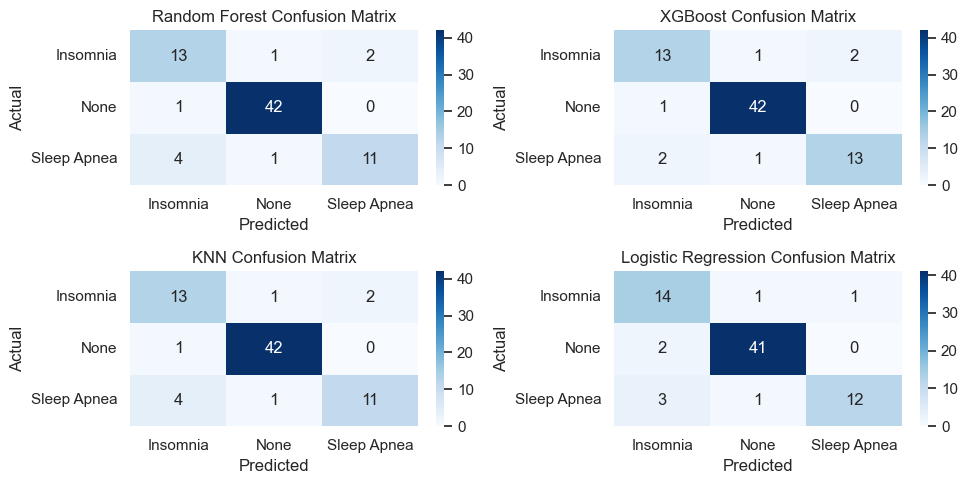

In [ ]:
# Confusion matrix plots for all 4 models
fig, axes = plt.subplots(2, 2, figsize=(10, 5))
axes = axes.flatten()

for i, (name, pipeline) in enumerate(pipelines.items()):
    y_pred = pipeline.predict(X_test)

    sns.heatmap(confusion_matrix(y_test, y_pred),
                annot=True, fmt='d', cmap='Blues',
                xticklabels=['Insomnia', 'None', 'Sleep Apnea'],
                yticklabels=['Insomnia', 'None', 'Sleep Apnea'],
                ax=axes[i])
    axes[i].set_title(f'{name} Confusion Matrix')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

plt.tight_layout()
plt.savefig('outputs/confusion_matrices.png', bbox_inches='tight')

plt.show()

### ✅ Overfitting Check

We compare **training accuracy** vs **test accuracy** for each model.  
A large gap (> 10%) means the model memorized training data and won't generalize well.

Our results:
- XGBoost: 93% train → 91% test (gap: **3%**) ✅ 
- Random Forest: 93% train → 88% test (gap: **5%**) ✅

Both models generalize well to unseen data.

In [ ]:
# Overfitting check
# Compare training and test scores
# Large gap means the model is overfitting

print("Model        | Train  | Test  | Diff")
print("-" * 45)
for name, pipeline in pipelines.items():
    train_score = pipeline.score(X_train, y_train)
    test_score = pipeline.score(X_test, y_test)
    fark = train_score - test_score
    print(f"{name:<20} | {train_score:.2f}  | {test_score:.2f} | {fark:.2f}")

Model        | Train  | Test  | Diff
---------------------------------------------
Random Forest        | 0.93  | 0.88 | 0.05
XGBoost              | 0.93  | 0.91 | 0.03
KNN                  | 0.92  | 0.88 | 0.04
Logistic Regression  | 0.92  | 0.89 | 0.03


### 📊 Model Comparison — Accuracy Chart

**Results:**
- **XGBoost: 0.91** — best performing model ✅
- Logistic Regression: 0.89
- Random Forest: 0.88
- KNN: 0.88

XGBoost outperforms all other models by learning from its own mistakes iteratively — each tree corrects the errors of the previous one.

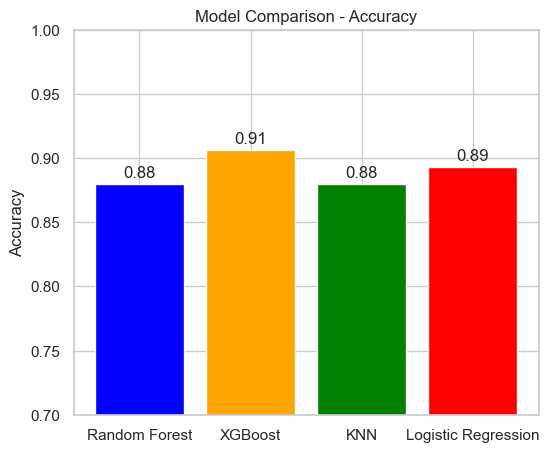

In [ ]:
# Accuracy comparison chart for all 4 models
plt.figure(figsize=(6, 5))
bars = plt.bar(results.keys(), results.values(),
               color=['blue', 'orange', 'green', 'red'])
plt.title('Model Comparison - Accuracy')
plt.ylabel('Accuracy')
plt.ylim(0.7, 1.0)

for bar, acc in zip(bars, results.values()):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{acc:.2f}', ha='center')

plt.savefig('outputs/model_comparison.png', bbox_inches='tight')
plt.show()

---
## 🔬 Section 6 — Model Explainability with SHAP

A high accuracy model is not enough — we need to understand **why** it makes each prediction.  
**SHAP (SHapley Additive exPlanations)** assigns each feature a contribution score for every individual prediction.

**Why this matters:**
- Doctors and clinicians need to trust the model's reasoning
- SHAP shows which features pushed the prediction toward Insomnia, Sleep Apnea, or None
- We apply SHAP on the best model: **XGBoost**

In [ ]:
import shap

X_test_transformed = pipelines['XGBoost'].named_steps['preprocessor'].transform(X_test)

explainer = shap.TreeExplainer(pipelines['XGBoost'].named_steps['model'])
shap_values = explainer.shap_values(X_test_transformed)

print("SHAP values calculated")
print("Shape:", shap_values.shape)

SHAP values calculated
Shape: (75, 24, 3)


In [ ]:
import shap

X_test_transformed = pipelines['XGBoost'].named_steps['preprocessor'].transform(X_test)

explainer = shap.TreeExplainer(pipelines['XGBoost'].named_steps['model'])
shap_values = explainer.shap_values(X_test_transformed)

print("SHAP values calculated")

SHAP values calculated


### 🔬 SHAP Summary Plots — Per Class

Each plot shows which features **most influenced** the model's prediction for that class.

**How to read:**
- Features are ranked from **most important (top) to least important (bottom)**
- **Red dots** = high feature value, **Blue dots** = low feature value
- Dot position on X axis = impact on prediction (right = pushes toward this class, left = pushes away)

---

**Insomnia:**
- High `Daily Steps` and high `Age` push strongly **toward** Insomnia
- High `Systolic_BP` pushes **away** from Insomnia
- Being female (`Gender_Female` high) slightly increases Insomnia risk

**None (Healthy):**
- High `Systolic_BP` pushes strongly **toward** healthy — low BP = more likely healthy
- Low `BMI Category` and low `Sleep Duration` reduce the chance of being healthy
- `Age` and `Daily Steps` also play a significant role

**Sleep Apnea:**
- High `Systolic_BP` (red dots on the right) is the **strongest predictor** of Sleep Apnea
- High `Age` also pushes toward Sleep Apnea risk
- High `Sleep Duration` actually **reduces** Sleep Apnea risk (blue dots push left)
- `Heart Rate` at high values increases the risk

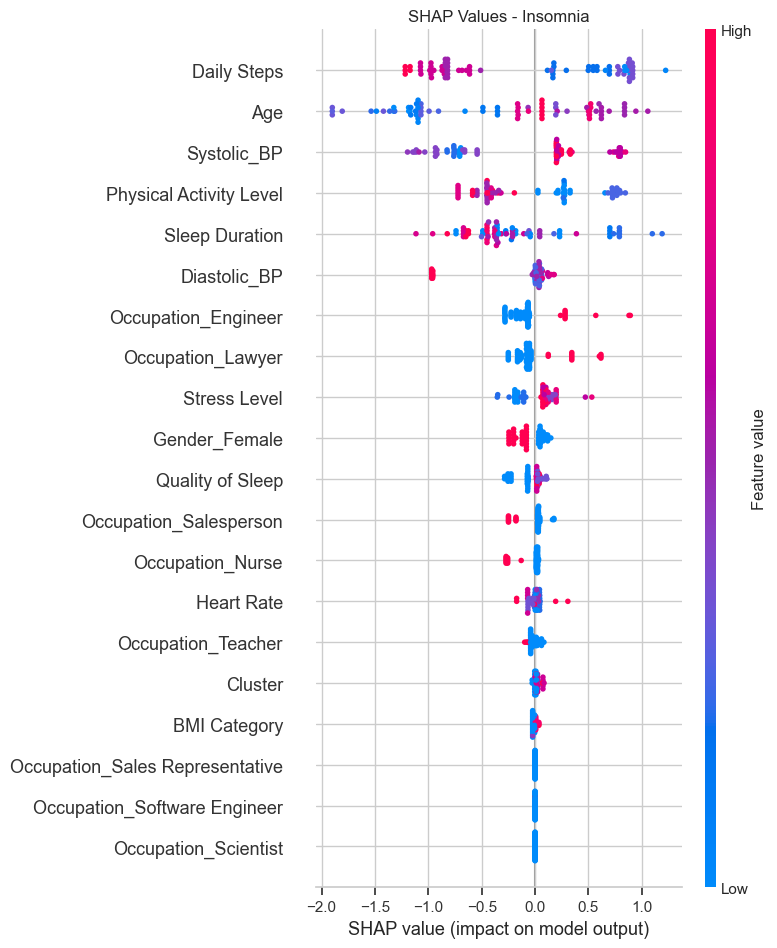

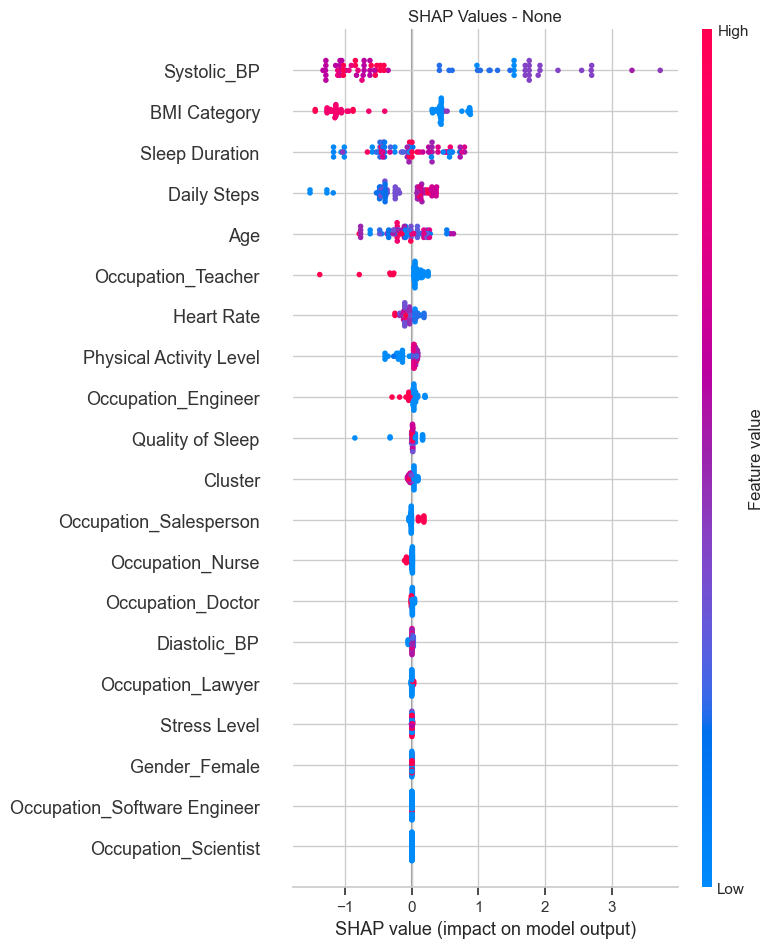

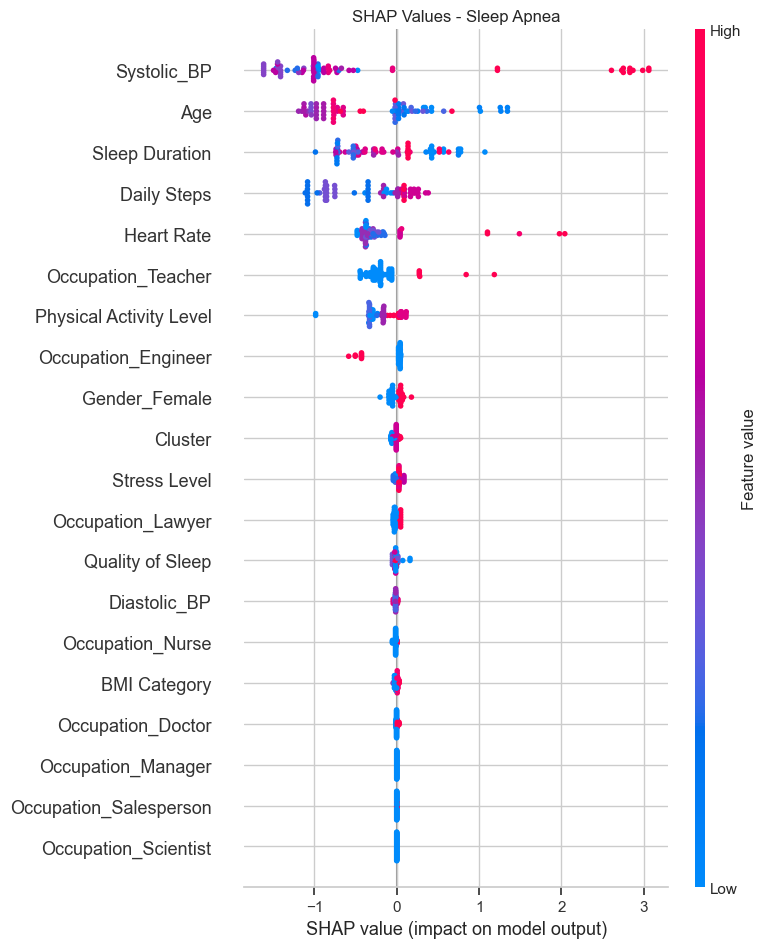

In [ ]:

ohe_colons = list(pipelines['XGBoost'].named_steps['preprocessor']
                    .named_transformers_['nominal']
                    .get_feature_names_out(['Gender', 'Occupation']))

all_cols = numerical_cols+ ohe_colons + ordinal_cols
class_names = ['Insomnia', 'None', 'Sleep Apnea']

for i,  class_name  in enumerate( class_names):
    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_values[:, :, i],
                      X_test_transformed,
                      feature_names=all_cols,
                      show=False)
    plt.title(f'SHAP Values - { class_name }')
    plt.savefig(f"outputs/importance_{ class_name .lower()}.png", dpi=300, bbox_inches="tight")           
    plt.show()

### 💾 Model Saving

We save all 4 model files to the `models/` folder:
- `xgboost_model.pkl` — the trained classifier
- `label_encoder.pkl` — to decode numeric predictions back to class names
- `kmeans_model.pkl` — to assign new users to a sleep profile cluster
- `scaler.pkl` — to scale new user input the same way as training data

The Streamlit app will load these files directly.

In [ ]:
import os
import joblib

# Create models directory if it doesn't exist
os.makedirs("models", exist_ok=True)

# ---- SAVE MODELS TO LOCAL FOLDER ----
# Streamlit app will load models directly from this folder
joblib.dump(pipelines["XGBoost"], "models/xgboost_model.pkl")
joblib.dump(le, "models/label_encoder.pkl")


joblib.dump(kmeans, "models/kmeans_model.pkl")
joblib.dump(scaler, "models/scaler.pkl")

print("All models saved successfully: xgboost, label_encoder, kmeans, scaler")
print(
    "All models successfully saved to the 'models/' folder."
)

All models saved successfully: xgboost, label_encoder, kmeans, scaler
All models successfully saved to the 'models/' folder.


## 🚀 Streamlit App

The clinical interface for this project was built with Streamlit.  
To launch the app locally:

```bash
streamlit run app.py
```

![App Screenshot](app_screenshot.png)